# Checking time of metrics

In [1]:
# Импорт библиотек
import os, sys
import argparse
import pandas as pd
from tqdm.auto import tqdm
from evaluate import load
import numpy as np
import seaborn as sns
import time
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

c:\HSE\project_poetry_2\ProjectPoetryRL\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
bertscore = load("bertscore")
sys.path.append('c:\\HSE\\project_poetry_2\\ProjectPoetryRL\\')
sys.path.append('c:\\HSE\\project_poetry_2\\ProjectPoetryRL\\prose-to-poetry')
sys.path.append('c:\\Program Files (x86)\\eSpeak\\command_line')

In [3]:
%cd c:\HSE\project_poetry_2\ProjectPoetryRL

c:\HSE\project_poetry_2\ProjectPoetryRL


c:\HSE\project_poetry_2\ProjectPoetryRL\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
from metrics import check_meter, check_meter_fast, \
        check_rhyme_scheme, get_rhyme_score, format_score,  embedding_sim_score, encode_sent

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Марина\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Model loaded with following settings:
  frequency_min: 3
           lang: ru
       max_iter: 20
          ngram: 3
   ngram_length: 3
   prob_ipa_min: 0.9
 prob_ngram_min: 0.9
     same_words: False
   stanza_limit: True
         stress: True
       syll_max: 2
    t_score_min: 3.078
   vowel_length: True
         window: 5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1184.83it/s]
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
def filter_lines(text):
    lines = []
    for line in text.split('\n'):
        line = line.strip()
        for ch in line:
            if ch.isalpha():
                lines.append(line)
                break
    return lines
    
def check_len(lines):
    if len(lines) == 4 or len(lines) == 8:
        return 1.
    return 0.

In [ ]:
from util import filter_lines as filter_lines_
def eval_metrics(df):
    outputs = df["output"].tolist()
    references = df["text"].tolist()

    times = {}

    # -------- format_score --------
    start = time.perf_counter()
    format_scores = []
    for output in df["output"]:
        lines = output.split('\n')
        f_lines = filter_lines_(lines)
        
        score = format_score(lines, f_lines)
        format_scores.append(score)
    times["format_score"] = time.perf_counter() - start
    format_scores = np.array(format_scores)

    # -------- rhyme_score_old --------
    start = time.perf_counter()
    rhyme_scores = []
    for i, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        rhyme_scores.append(
            check_rhyme_scheme(lines, row["rhyme_scheme"])
        )
    times["rhyme_score"] = time.perf_counter() - start
    rhyme_scores = np.array(rhyme_scores)
    
    # -------- rhyme_score_new --------
    start = time.perf_counter()
    rhyme_scores_new = []
    for i, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        rhyme_scores_new.append(
            get_rhyme_score(lines, row["rhyme_scheme"])
        )
    times["rhyme_score_new"] = time.perf_counter() - start
    rhyme_scores_new = np.array(rhyme_scores_new)

    # -------- meter_score --------
    start = time.perf_counter()
    meter_scores = []
    for i, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        meter_scores.append(
            check_meter(lines, row["meter"])
        )
    times["meter_score"] = time.perf_counter() - start
    meter_scores = np.array(meter_scores)

    # -------- meter_score_fast --------
    start = time.perf_counter()
    meter_scores2 = []
    for i, row in tqdm(df.iterrows(), total=len(df)):
        lines = filter_lines(row["output"])[:8]
        meter_scores2.append(
            check_meter_fast(lines, row["meter"], row['rhyme_scheme'])
        )
    times["meter_score_fast"] = time.perf_counter() - start
    meter_scores2 = np.array(meter_scores2)

    
    # -------- BERTScore --------
    start = time.perf_counter()
    bertscore_ = bertscore.compute(
        predictions=outputs,
        references=references,
        lang="ru"
    )
    times["BERTscore"] = time.perf_counter() - start
    bert_scores = np.array(bertscore_["f1"])

    # -------- entailment --------
    '''
    start = time.perf_counter()
    batch_size = 8  # можно увеличивать, зависит от GPU
    entailment_scores = []

    for i in tqdm(range(0, len(df), batch_size)):
        batch_prose = df["text"].iloc[i:i+batch_size].tolist()
        batch_poem = df["output"].iloc[i:i+batch_size].tolist()

        # pipeline принимает словарь с текстами и текстами-парами
        batch_res = nli(
            [{"text": p, "text_pair": h} for p, h in zip(batch_prose, batch_poem)],
            top_k=None,
        )
        for res in batch_res:
            score = {r["label"]: r["score"] for r in res}
            entailment_scores.append(score.get("entailment", 0.0))
    times["entailment"] = time.perf_counter() - start
    entailment_scores = np.array(entailment_scores)
    '''

    # -------- cos sentense --------
    emb_prose = encode_sent(references) # можно посчитать заранее поэтому не учитывается в подсчете времени
    start = time.perf_counter()
    emb_poem = encode_sent(outputs)
    #cos_sim = (emb_prose * emb_poem).sum(dim=1).cpu().numpy()
    cos_sim = F.cosine_similarity(emb_prose, emb_poem, dim=1).cpu().numpy()
    times["semantic_embeddings"] = time.perf_counter() - start
    cos_sim = np.array(cos_sim)

    # -------- статистика --------
    metrics = {
        "BERTscore": bert_scores,
        #"entailment": entailment_scores,
        "semantic_embeddings": cos_sim,
        "format_score": format_scores,
        "rhyme_score": rhyme_scores,
        "rhyme_score_new": rhyme_scores_new,
        "meter_score": meter_scores,
        "meter_score_fast": meter_scores2
    }

    stats = []
    for name, scores in metrics.items():
        stats.append({
            "metric": name,
            "mean": scores.mean(),
            "std": scores.std(),
            "time_sec": times[name] / len(df)
        })

    stats_df = pd.DataFrame(stats).set_index("metric")

    print("\nMetric statistics:")
    print(stats_df)

    return stats_df, metrics

def viz_metrics(metrics):
    # -------- распределения --------
    plt.figure(figsize=(15, 10))

    for i, (name, scores) in enumerate(metrics.items(), 1):
        plt.subplot(2, 4, i)
        plt.hist(scores, bins=30)
        plt.title(name)

    plt.tight_layout()
    plt.show()

    df_metrics = pd.DataFrame(metrics)
    corr = df_metrics.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Корреляция между метриками")
    plt.show()

In [12]:
test_dataset = 'dataset/prosa_test_text_prev.csv'
input_file = 'output/qwen.csv'

inputs = pd.read_csv(test_dataset)
outputs = pd.read_csv(input_file)
df = pd.concat([inputs, outputs], axis=1).rename({'qwen': 'output'}, axis=1)

In [13]:
stats_df, metrics = eval_metrics(df)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:05<00:00, 171.50it/s]



Metric statistics:
                         mean       std  time_sec
metric                                           
BERTscore            0.773638  0.073938  0.153218
semantic_embeddings  0.839702  0.100604  0.103982
len_score            0.963753  0.135939  0.000023
rhyme_score          0.043525  0.147585  0.242566
rhyme_score_new      0.053884  0.144477  0.251015
meter_score          0.408783  0.109070  0.007873
meter_score_fast     0.710676  0.068141  0.005835


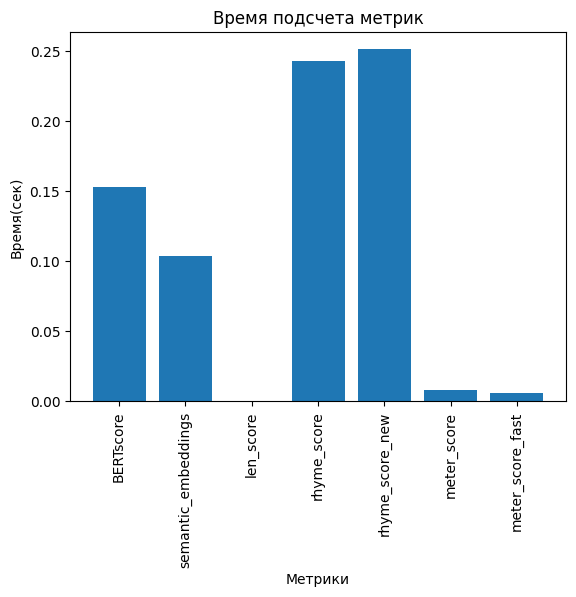

In [14]:
stats_df_ = stats_df.copy()#.drop('entailment')
plt.bar(stats_df_.index, stats_df_['time_sec'])

plt.xlabel("Метрики")
plt.ylabel("Время(сек)")
plt.title("Время подсчета метрик")
plt.xticks(rotation=90)
plt.show()

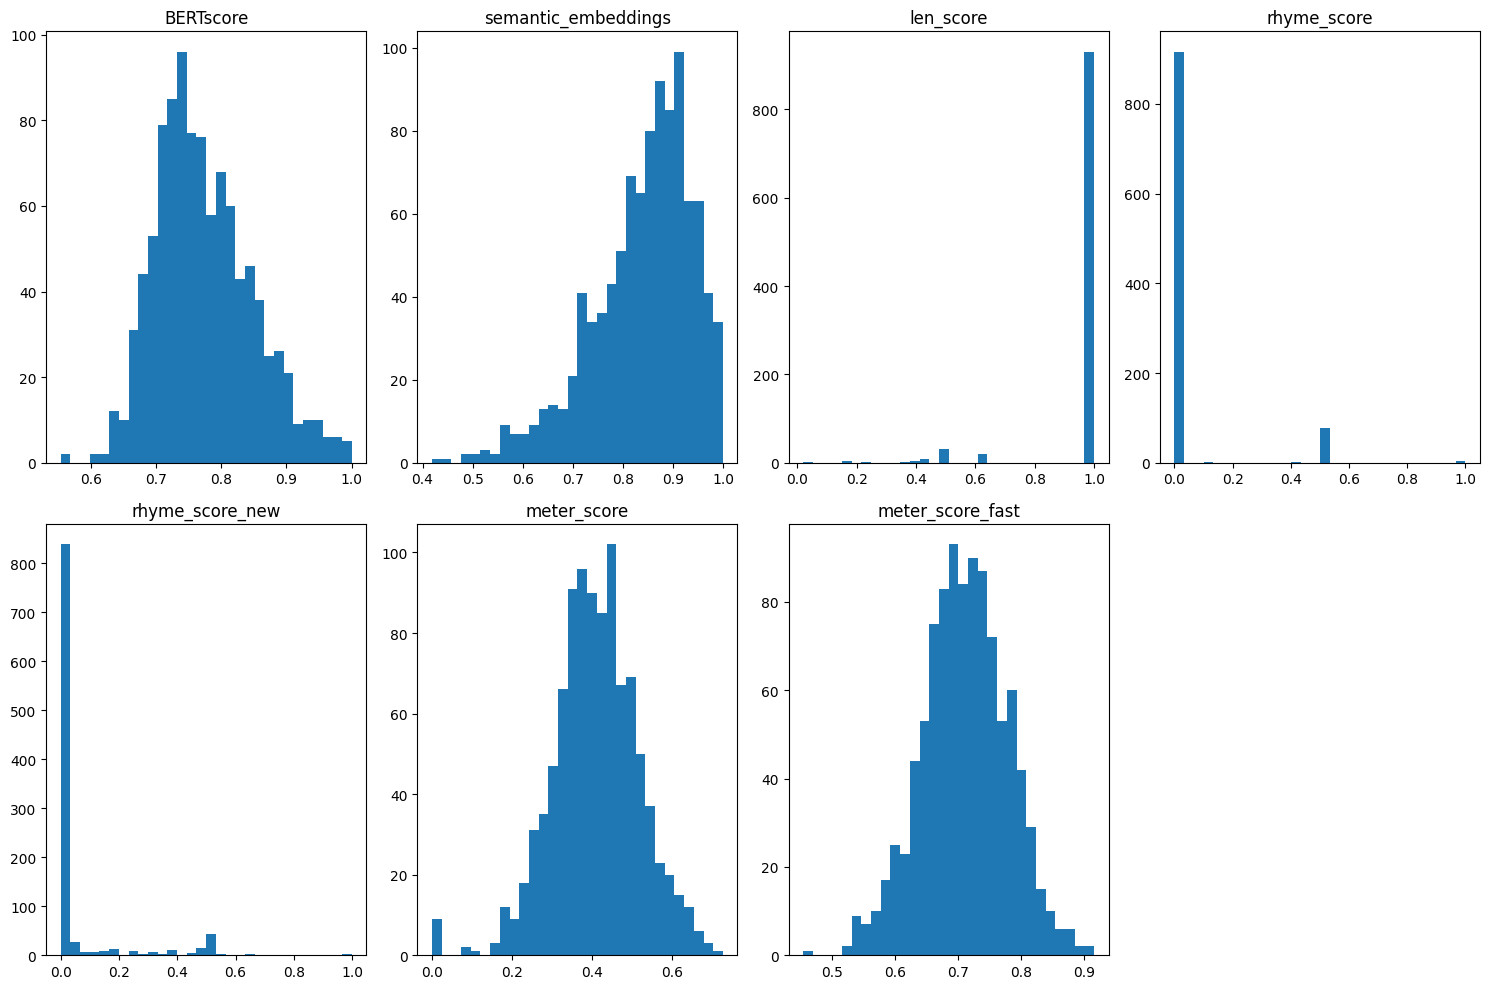

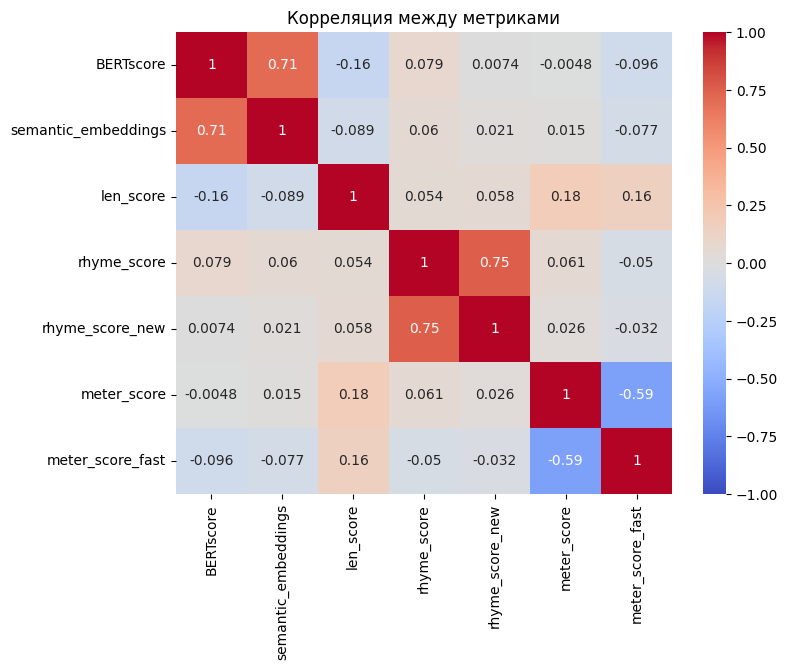

In [15]:
metrics_ = metrics.copy()
viz_metrics(metrics_)

In [21]:
cosine = np.array(metrics["semantic_embeddings"])
bert = np.array(metrics["BERTscore"])

# разница
diff = cosine - bert

# индексы
top_cosine_idx = np.argsort(-diff)[:10]   # cosine сильно больше
top_bert_idx = np.argsort(diff)[:10]      # bertscore сильно больше

def print_examples(indices, title):
    print(f"\n{'='*20} {title} {'='*20}")
    for i in indices:
        print(f"\nIndex: {i}")
        print(f"Cosine: {cosine[i]:.4f} | BERTScore: {bert[i]:.4f} | Diff: {diff[i]:.4f}")
        print(f"\nSRC:\n{df['text'][i]}")
        print(f"\nGEN:\n{df['output'][i]}")
        print("-"*50)

# вывод
print_examples(top_cosine_idx, "Cosine >> BERTScore")
print_examples(top_bert_idx, "BERTScore >> Cosine")


==================== Cosine >> BERTScore ====================

Index: 951
Cosine: 0.8756 | BERTScore: 0.6431 | Diff: 0.2325

SRC:
Разоблаченные владыки мира не могут противопоставить наполеоновскому идеалу славы и величия, не имеющего смысла, никакого разумного идеала.


GEN:
Не владыки мирозданья силы,
Наполеона идеал не удержит,
Безумный стремленье славы путь
В безбрежье мглы непостижим.
--------------------------------------------------

Index: 397
Cosine: 0.9359 | BERTScore: 0.7053 | Diff: 0.2306

SRC:
Он молился, просил бога помочь ему, вселиться в него и очистить его, а между тем то, о чем он просил, уже совершилось.


GEN:
Молился он, бога молил,
Чтоб в душу его войти,
И очистить грехи свои,
А то, о чем молил, уже было.

Он молился, чтоб в себя войти,
Бога просил помочь,
Чтоб очистить сердце свое,
А то, о чем молил, уже было.
--------------------------------------------------

Index: 890
Cosine: 0.9116 | BERTScore: 0.6843 | Diff: 0.2273

SRC:
Она разливала чай – слушая неистощи

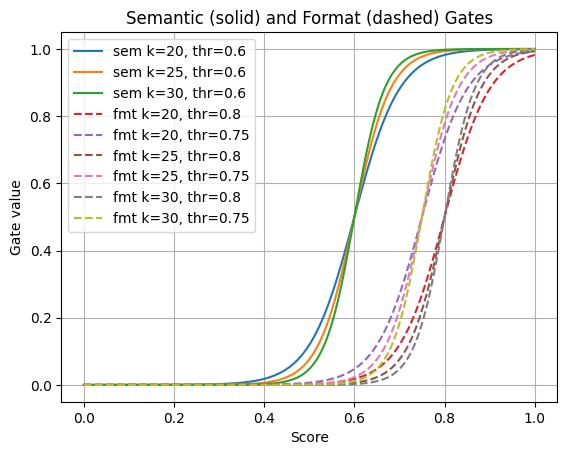

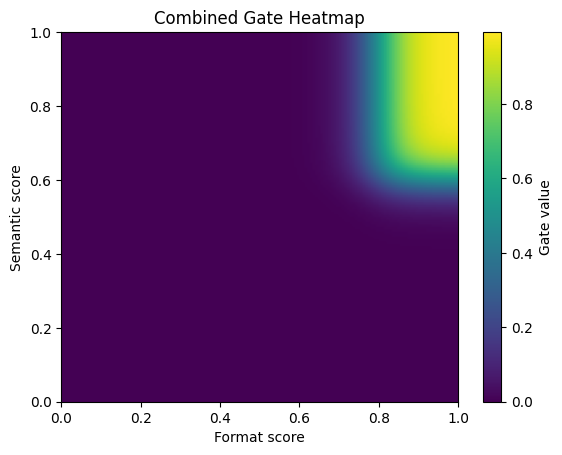

Gate(1,1) = 0.993301
⚠️ Gate далеко от 1 — возможно слишком мягкие параметры


In [17]:
import torch
import matplotlib.pyplot as plt

def compute_gate(sem_scores, format_scores,
                 k_sem=8.0, k_format=5.0,
                 sem_thr=0.7, format_thr=0.9):
    gate_sem = torch.sigmoid(k_sem * (sem_scores - sem_thr))
    gate_fmt = torch.sigmoid(k_format * (format_scores - format_thr))
    return gate_sem * gate_fmt


def check_gate_at_one(k_sem=8.0, k_format=5.0,
                      sem_thr=0.7, format_thr=0.9,
                      tol=1e-3):
    sem = torch.tensor([1.0])
    fmt = torch.tensor([1.0])

    gate = compute_gate(sem, fmt, k_sem, k_format, sem_thr, format_thr)

    print(f"Gate(1,1) = {gate.item():.6f}")

    if abs(gate.item() - 1.0) < tol:
        print("✅ OK: gate ≈ 1")
    else:
        print("⚠️ Gate далеко от 1 — возможно слишком мягкие параметры")


def plot_gates(
    k_sem_list=(8.0,),
    k_format_list=(5.0,),
    sem_thr_list=(0.7,),
    format_thr_list=(0.9,),
    num_points=200
):
    """
    Рисует отдельные сигмоиды для semantic и format
    """
    scores = torch.linspace(0, 1, num_points)

    plt.figure()

    # Semantic (сплошные линии)
    for k_sem in k_sem_list:
        for sem_thr in sem_thr_list:
            gate_sem = torch.sigmoid(k_sem * (scores - sem_thr))
            plt.plot(
                scores.numpy(),
                gate_sem.numpy(),
                label=f"sem k={k_sem}, thr={sem_thr}"
            )

    # Format (пунктир)
    for k_fmt in k_format_list:
        for fmt_thr in format_thr_list:
            gate_fmt = torch.sigmoid(k_fmt * (scores - fmt_thr))
            plt.plot(
                scores.numpy(),
                gate_fmt.numpy(),
                linestyle="--",
                label=f"fmt k={k_fmt}, thr={fmt_thr}"
            )

    plt.xlabel("Score")
    plt.ylabel("Gate value")
    plt.title("Semantic (solid) and Format (dashed) Gates")
    plt.legend()
    plt.grid()
    plt.show()


def plot_combined_gate(
    k_sem=8.0,
    k_format=5.0,
    sem_thr=0.7,
    format_thr=0.9,
    num_points=150
):
    """
    Heatmap для итогового gate = gate_sem * gate_fmt
    """
    sem = torch.linspace(0, 1, num_points)
    fmt = torch.linspace(0, 1, num_points)

    sem_grid, fmt_grid = torch.meshgrid(sem, fmt, indexing="ij")

    gate_sem = torch.sigmoid(k_sem * (sem_grid - sem_thr))
    gate_fmt = torch.sigmoid(k_format * (fmt_grid - format_thr))
    gates = gate_sem * gate_fmt

    plt.figure()
    plt.imshow(
        gates.numpy(),
        origin="lower",
        extent=[0, 1, 0, 1],
        aspect="auto"
    )
    plt.xlabel("Format score")
    plt.ylabel("Semantic score")
    plt.title("Combined Gate Heatmap")
    plt.colorbar(label="Gate value")
    plt.show()


# ===== Примеры =====

# 1. Посмотреть разные параметры
plot_gates(
    k_sem_list=[20, 25, 30],
    k_format_list=[ 20, 25, 30],
    sem_thr_list=[ 0.6],
    format_thr_list=[ 0.8, 0.75]
)

# 2. Heatmap текущего гейта
plot_combined_gate(k_sem=30.0,
    k_format=25.0,
    sem_thr=0.6,
    format_thr=0.8,)

check_gate_at_one(k_sem=30.0,
    k_format=25.0,
    sem_thr=0.6,
    format_thr=0.8,)